# Dislib tutorial

This tutorial will show the basics of using [dislib](https://dislib.bsc.es).


## Setup


First, we need to start an interactive PyCOMPSs session:

In [1]:
import os
os.environ["ComputingUnits"] = "1"

import pycompss.interactive as ipycompss
if 'BINDER_SERVICE_HOST' in os.environ:
    ipycompss.start(graph=True,
                    project_xml='../xml/project.xml',
                    resources_xml='../xml/resources.xml')
else:
    ipycompss.start(graph=True, monitor=1000)

********************************************************
**************** PyCOMPSs Interactive ******************
********************************************************
*          .-~~-.--.           ______        _   _     *
*         :         )         |____  \      | | | |    *
*   .~ ~ -.\       /.- ~~ .      __) |      | |_| |_   *
*   >       `.   .'       <     |__  |      |___   _|  *
*  (         .- -.         )   ____) |   _      | |    *
*   `- -.-~  `- -'  ~-.- -'   |______/  |_|     |_|    *
*     (        :        )           _ _ .-:            *
*      ~--.    :    .--~        .-~  .-~  }            *
*          ~-.-^-.-~ \_      .~  .-~   .~              *
*                   \ \ '     \ '_ _ -~                *
*                    \`.\`.    //                      *
*           . - ~ ~-.__\`.\`-.//                       *
*       .-~   . - ~  }~ ~ ~-.~-.                       *
*     .' .-~      .-~       :/~-.~-./:                 *
*    /_~_ _ . - ~              

* - Log path : /home/user/.COMPSs/Interactive_13/
* - PyCOMPSs Runtime started... Have fun!              *
********************************************************


Next, we import dislib and we are all set to start working!

In [2]:
import dislib as ds

## Distributed arrays

The main data structure in dislib is the distributed array (or ds-array). These arrays are a distributed representation of a 2-dimensional array that can be operated as a regular Python object. Usually, rows in the array represent samples, while columns represent features.

To create a random array we can run the following NumPy-like command:

In [3]:
x = ds.random_array(shape=(500, 500), block_size=(100, 100))
print(x.shape)
x

(500, 500)


ds-array(blocks=(...), top_left_shape=(100, 100), reg_shape=(100, 100), shape=(500, 500), sparse=False)

Now `x` is a 500x500 ds-array of random numbers stored in blocks of 100x100 elements. Note that `x` is not stored in memory. Instead, `random_array` generates the contents of the array in tasks that are usually executed remotely. This allows the creation of really big arrays.

The content of `x` is a list of `Futures` that represent the actual data (wherever it is stored).

To see this, we can access the `_blocks` field of `x`:

In [4]:
x._blocks[0][0]

`block_size` is useful to control the granularity of dislib algorithms.

To retrieve the actual contents of `x`, we use `collect`, which synchronizes the data and returns the equivalent NumPy array:

In [5]:
x.collect()

array([[0.48604732, 0.68571232, 0.98557605, ..., 0.51530027, 0.39511585,
        0.42942001],
       [0.03398195, 0.40964073, 0.5437061 , ..., 0.16162333, 0.79046618,
        0.71677277],
       [0.82399233, 0.80869154, 0.16965568, ..., 0.79380114, 0.31004525,
        0.51511589],
       ...,
       [0.57630698, 0.72028925, 0.11842501, ..., 0.92236462, 0.5837854 ,
        0.92114111],
       [0.84521256, 0.17909749, 0.42140394, ..., 0.95331429, 0.01587735,
        0.58532187],
       [0.81065273, 0.5666422 , 0.65635218, ..., 0.58820423, 0.42493203,
        0.84351429]], shape=(500, 500))

Another way of creating ds-arrays is using array-like structures like NumPy arrays or lists:

In [6]:
x1 = ds.array([[1, 2, 3], [4, 5, 6]], block_size=(1, 3))
x1

ds-array(blocks=(...), top_left_shape=(1, 3), reg_shape=(1, 3), shape=(2, 3), sparse=False)

Distributed arrays can also store sparse data in CSR format:

In [7]:
from scipy.sparse import csr_matrix

sp = csr_matrix([[0, 0, 1], [1, 0, 1]])
x_sp = ds.array(sp, block_size=(1, 3))
x_sp

ds-array(blocks=(...), top_left_shape=(1, 3), reg_shape=(1, 3), shape=(2, 3), sparse=True)

In this case, `collect` returns a CSR matrix as well:

In [8]:
x_sp.collect()

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (2, 3)>

### Loading data

A typical way of creating ds-arrays is to load data from disk. Dislib currently supports reading data in CSV and SVMLight formats like this:

In [9]:
x, y = ds.load_svmlight_file("./files/libsvm/1", block_size=(20, 100), n_features=780, store_sparse=True)

print(x)

csv = ds.load_txt_file("./files/csv/1", block_size=(500, 122))

print(csv)

ds-array(blocks=(...), top_left_shape=(20, 100), reg_shape=(20, 100), shape=(61, 780), sparse=True)
ds-array(blocks=(...), top_left_shape=(500, 122), reg_shape=(500, 122), shape=(4235, 122), sparse=False)


### Slicing

Similar to NumPy, ds-arrays support the following types of slicing:

(Note that slicing a ds-array creates a new ds-array)

In [10]:
x = ds.random_array((50, 50), (10, 10))

Get a single row:

In [11]:
x[4]

ds-array(blocks=(...), top_left_shape=(1, 10), reg_shape=(10, 10), shape=(1, 50), sparse=False)

Get a single element:

In [12]:
x[2, 3]

ds-array(blocks=(...), top_left_shape=(1, 1), reg_shape=(1, 1), shape=(1, 1), sparse=False)

Get a set of rows or a set of columns:

In [13]:
# Consecutive rows
print(x[10:20])

# Consecutive columns
print(x[:, 10:20])

# Non consecutive rows
print(x[[3, 7, 22]])

# Non consecutive columns
print(x[:, [5, 9, 48]])

ds-array(blocks=(...), top_left_shape=(10, 10), reg_shape=(10, 10), shape=(10, 50), sparse=False)
ds-array(blocks=(...), top_left_shape=(10, 10), reg_shape=(10, 10), shape=(50, 10), sparse=False)
ds-array(blocks=(...), top_left_shape=(3, 10), reg_shape=(10, 10), shape=(3, 50), sparse=False)
ds-array(blocks=(...), top_left_shape=(10, 3), reg_shape=(10, 10), shape=(50, 3), sparse=False)


Get any set of elements:

In [14]:
x[0:5, 40:45]

ds-array(blocks=(...), top_left_shape=(5, 5), reg_shape=(10, 10), shape=(5, 5), sparse=False)

### Other functions

Apart from this, ds-arrays also provide other useful operations like `transpose` and `mean`:

In [15]:
x.mean(axis=0).collect()

array([0.51352356, 0.49396794, 0.4661033 , 0.48026991, 0.50136143,
       0.49323405, 0.51248831, 0.51658519, 0.4904544 , 0.47166468,
       0.50245676, 0.49936659, 0.47499634, 0.52566765, 0.53676456,
       0.59127036, 0.50947458, 0.47320677, 0.42695456, 0.54335201,
       0.51780756, 0.49855486, 0.53845333, 0.37299501, 0.51229418,
       0.43110043, 0.47262688, 0.41698864, 0.54994596, 0.46676007,
       0.46070067, 0.48861301, 0.45868291, 0.53380687, 0.50555055,
       0.53453463, 0.43711111, 0.52115681, 0.48152436, 0.49215593,
       0.41552034, 0.47669533, 0.5610678 , 0.43511911, 0.49611885,
       0.44116871, 0.42241364, 0.48626255, 0.51636529, 0.44251849])

In [16]:
x.transpose().collect()

array([[0.02733543, 0.65891797, 0.36654465, ..., 0.52109164, 0.86395718,
        0.93593907],
       [0.41462264, 0.97419918, 0.14124931, ..., 0.15893453, 0.49486474,
        0.14138483],
       [0.91312707, 0.53860404, 0.96686988, ..., 0.78763956, 0.18268972,
        0.20551984],
       ...,
       [0.19468602, 0.62184611, 0.81007025, ..., 0.88719987, 0.55132466,
        0.32694948],
       [0.19221646, 0.64678511, 0.98416872, ..., 0.18736269, 0.51392039,
        0.59614856],
       [0.49591758, 0.17913008, 0.11419029, ..., 0.02701779, 0.22316829,
        0.78426262]], shape=(50, 50))

## Machine learning with dislib

Dislib provides an estimator-based API very similar to [scikit-learn](https://scikit-learn.org/stable/). To run an algorithm, we first create an estimator. For example, a K-means estimator:

In [17]:
from dislib.cluster import KMeans

km = KMeans(n_clusters=3)

Now, we create a ds-array with some blob data, and fit the estimator:

In [18]:
from sklearn.datasets import make_blobs

# create ds-array
x, y = make_blobs(n_samples=1500)
x_ds = ds.array(x, block_size=(500, 2))

km.fit(x_ds)

,n_clusters,3
,init,'random'
,max_iter,10
,tol,0.0001
,arity,50
,random_state,RandomState(M...0x7FDE1B1AAE40
,verbose,False


Finally, we can make predictions on new (or the same) data:

In [19]:
y_pred = km.predict(x_ds)
y_pred

ds-array(blocks=(...), top_left_shape=(500, 1), reg_shape=(500, 1), shape=(1500, 1), sparse=False)

`y_pred` is a ds-array of predicted labels for `x_ds`

Let's plot the results

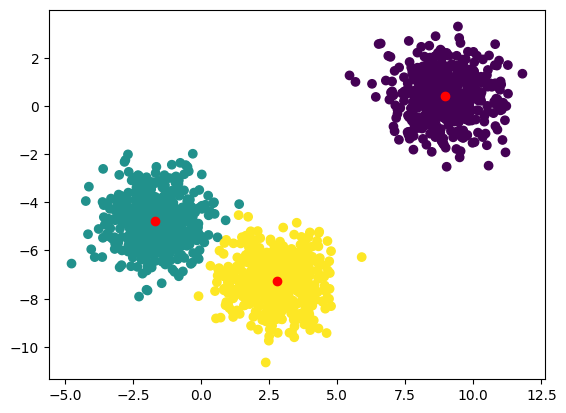

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt


centers = km.centers

# set the color of each sample to the predicted label
plt.scatter(x[:, 0], x[:, 1], c=y_pred.collect())

# plot the computed centers in red
plt.scatter(centers[:, 0], centers[:, 1], c='red')

Note that we need to call `y_pred.collect()` to retrieve the actual labels and plot them. The rest is the same as if we were using scikit-learn.

Now let's try a more complex example that uses some preprocessing tools.

First, we load a classification data set from scikit-learn into ds-arrays. 

Note that this step is only necessary for demonstration purposes. Ideally, your data should be already loaded in ds-arrays.

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

x, y = load_breast_cancer(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(x, y)

x_train = ds.array(x_train, block_size=(100, 10))
y_train = ds.array(y_train.reshape(-1, 1), block_size=(100, 1))

x_test = ds.array(x_test, block_size=(100, 10))
y_test = ds.array(y_test.reshape(-1, 1), block_size=(100, 1))

Next, we can see how support vector machines perform in classifying the data. We first fit the model (ignore any warnings in this step):

In [22]:
from dislib.classification import CascadeSVM

csvm = CascadeSVM()

csvm.fit(x_train, y_train)

,cascade_arity,2
,max_iter,5
,tol,0.001
,kernel,'rbf'
,c,1
,gamma,'auto'
,check_convergence,True
,random_state,None
,verbose,False


and now we can make predictions on new data using `csvm.predict()`, or we can get the model accuracy on the test set with:

In [23]:
score = csvm.score(x_test, y_test)

`score` represents the classifier accuracy, however, it is returned as a `Future`. We need to synchronize to get the actual value:

In [24]:
from pycompss.api.api import compss_wait_on

print(compss_wait_on(score))

0.6503496503496503


The accuracy should be around 0.6, which is not very good. We can scale the data before classification to improve accuracy. This can be achieved using dislib's `StandardScaler`.

The `StandardScaler` provides the same API as other estimators. In this case, however, instead of making predictions on new data, we transform it:

In [25]:
from dislib.preprocessing import StandardScaler

sc = StandardScaler()

# fit the scaler with train data and transform it
scaled_train = sc.fit_transform(x_train)

# transform test data
scaled_test = sc.transform(x_test)

Now `scaled_train` and `scaled_test` are the scaled samples. Let's see how SVM performs now.

In [26]:
csvm.fit(scaled_train, y_train)
score = csvm.score(scaled_test, y_test)
print(compss_wait_on(score))

0.993006993006993


The new accuracy should be around 0.9, which is a great improvement!

### Close the session

To finish the session, we need to stop PyCOMPSs:

In [27]:
ipycompss.stop()

********************************************************
***************** STOPPING PyCOMPSs ********************
********************************************************
Checking if any issue happened.
         have not been brought to the master.
********************************************************
